# Waveform Acquisition from Tektronix DPO 2014B using `tm_devices`

This notebook connects to a Tektronix DPO 2014B oscilloscope over Ethernet using `tm_devices` with the pure-Python `pyvisa-py` backend, retrieves active channel waveforms, saves the data to a CSV file, and plots them inline.

In [54]:
# import numpy as np
# import matplotlib.pyplot as plt
# from tm_devices import DeviceManager
# from tm_devices.helpers import PYVISA_PY_BACKEND
# from tm_devices.helpers.singleton_metaclass import Singleton

# # Enable inline plotting
# %matplotlib inline

## 1. Connect to Oscilloscope

Use the `DeviceManager` from `tm_devices` to handle connection lifetime. We explicitly use the pure-Python `@py` backend (`PYVISA_PY_BACKEND`) and define a compatibility-friendly VXI-11 resource string `TCPIP::<IP>::INSTR`.

In [55]:
# import subprocess

# IP_ADDRESS = "10.10.10.2"
# resource_expression = f"TCPIP::{IP_ADDRESS}::INSTR"

# # 1. Pre-connection Ping Check
# print(f"Pinging oscilloscope at {IP_ADDRESS}...")
# ping_response = subprocess.run(
#     ["ping", "-c", "1", "-W", "1", IP_ADDRESS],
#     stdout=subprocess.DEVNULL,
#     stderr=subprocess.DEVNULL
# )

# if ping_response.returncode != 0:
#     print(f"\n[ERROR] Oscilloscope at {IP_ADDRESS} is NOT reachable!")
#     print("Please verify:")
#     print(" 1. The physical Ethernet cable is plugged in on both ends.")
#     print(" 2. The oscilloscope is powered on.")
#     print(" 3. Your laptop's Ethernet connection is active and configured with static IP 10.10.10.1.")
#     print("\nYou can run the following command in a terminal to check your network interfaces:")
#     print("  ip addr")
#     print("\nTo automatically bring up the configured static IP connection:")
#     print("  nmcli connection up \"Wired connection 1\"")
# else:
#     print("Oscilloscope is reachable via ping.")
#     print(f"Connecting to oscilloscope at {IP_ADDRESS} using tm_devices...")

#     # 2. Prevent Singleton re-instantiation warnings in Jupyter notebooks
#     if DeviceManager in Singleton._class_instances:
#         dm = Singleton._class_instances[DeviceManager]
#         # If the DeviceManager was closed in a previous cell execution, reopen it
#         if not dm.is_open:
#             dm.open()
#     else:
#         dm = DeviceManager()

#     dm.visa_library = PYVISA_PY_BACKEND

#     try:
#         # 3. Establish the VISA connection
#         scope = dm.add_unsupported_device(resource_expression)
#         idn = scope.query("*IDN?")
#         print(f"\nSuccessfully connected: {idn.strip()}")
#     except Exception as e:
#         print(f"\nConnection failed: {e}")


## 2. Detect Active Channels

Queries the oscilloscope to see which analog channels (CH1-CH4) are currently turned on.

In [56]:
# active_channels = []
# for ch in ["CH1", "CH2", "CH3", "CH4"]:
#     is_active = scope.query(f"SELect:{ch}?").strip()
#     if is_active == "1":
#         active_channels.append(ch)

# print(f"Active channels detected: {active_channels}")

## 3. Acquire Waveform Data

For each active channel, we:
1. Configure the data source and formatting (16-bit signed binary).
2. Retrieve vertical scaling (multiplier, offset) and horizontal scaling (sampling interval) parameters.
3. Download and parse the raw binary curve using `query_binary_values` from the `tm_devices` API (which wraps PyVISA to automatically decode the IEEE 488.2 block header and output a NumPy array).
4. Scale the raw integers into physical voltages.

In [57]:
# Set data format parameters
scope.write("DATa:ENCdg RIBinary")  # Signed integer binary format
scope.write("DATa:WIDth 2")        # 16-bit resolution

raw_waveforms = {}
scaling_params = {}

for ch in active_channels:
    print(f"Acquiring {ch}...")
    scope.write(f"DATa:SOUrce {ch}")
    
    # Get record length
    record_length = int(scope.query("HORizontal:RECOrdlength?").strip())
    scope.write("DATa:STARt 1")
    scope.write(f"DATa:STOP {record_length}")
    
    # Retrieve and store scaling parameters
    scaling_params[ch] = {
        "xincr": float(scope.query("WFMPre:XINcr?").strip()),
        "xzero": float(scope.query("WFMPre:XZEro?").strip()),
        "pt_off": float(scope.query("WFMPre:PT_Off?").strip()),
        "ymult": float(scope.query("WFMPre:YMUlt?").strip()),
        "yoff": float(scope.query("WFMPre:YOFf?").strip()),
        "yzero": float(scope.query("WFMPre:YZEro?").strip()),
        "yunit": scope.query("WFMPre:YUNit?").strip().replace('"', ''),
        "xunit": scope.query("WFMPre:XUNit?").strip().replace('"', '')
    }
    
    # Download and parse curve
    # We retrieve it as a list and convert to numpy array to avoid an internal
    # numpy truth value bug in tm_devices (where it checks 'if not response:')
    raw_ints = np.array(
        scope.query_binary(
            "CURVe?",
            datatype="h",         # 'h' = signed 16-bit short
            is_big_endian=True    # RIBinary with 2 bytes is big-endian
        )
    )
    raw_waveforms[ch] = raw_ints

print("Raw waveforms acquired successfully!")


2026-07-09 11:31:04.429696 - (SCOPE 1) Write >>  'DATa:ENCdg RIBinary'
2026-07-09 11:31:04.448490 - (SCOPE 1) Write >>  'DATa:WIDth 2'
Acquiring CH1...
2026-07-09 11:31:04.465672 - (SCOPE 1) Write >>  'DATa:SOUrce CH1'
2026-07-09 11:31:04.483174 - (SCOPE 1) Query >>  'HORizontal:RECOrdlength?'
2026-07-09 11:31:04.503518 - Response from 'HORizontal:RECOrdlength?' >>  '125000'
2026-07-09 11:31:04.504530 - (SCOPE 1) Write >>  'DATa:STARt 1'
2026-07-09 11:31:04.522098 - (SCOPE 1) Write >>  'DATa:STOP 125000'
2026-07-09 11:31:04.541037 - (SCOPE 1) Query >>  'WFMPre:XINcr?'
2026-07-09 11:31:04.695618 - Response from 'WFMPre:XINcr?' >>  '8.0000E-6'
2026-07-09 11:31:04.696856 - (SCOPE 1) Query >>  'WFMPre:XZEro?'
2026-07-09 11:31:04.835008 - Response from 'WFMPre:XZEro?' >>  '-500.0000E-3'
2026-07-09 11:31:04.836696 - (SCOPE 1) Query >>  'WFMPre:PT_Off?'
2026-07-09 11:31:04.859188 - Response from 'WFMPre:PT_Off?' >>  '0'
2026-07-09 11:31:04.860235 - (SCOPE 1) Query >>  'WFMPre:YMUlt?'
2026-07-

## 4. Scale Waveform Data

Applies the horizontal and vertical scaling factors to convert raw digitizing levels into physical units (seconds and volts), including scaling Channel 4 by a factor of 10.

In [58]:
waveforms = {}
time_axis = None
yunit = "V"
xunit = "s"

for ch in raw_waveforms.keys():
    params = scaling_params[ch]
    raw_ints = raw_waveforms[ch]
    
    yunit = params["yunit"]
    xunit = params["xunit"]
    if xunit == "V" or not xunit:
        xunit = "s"
        
    # Scale data to physical units
    scaled_data = (raw_ints - params["yoff"]) * params["ymult"] + params["yzero"]
    
    # Scale Channel 4 ten times
    if ch == "CH4":
        scaled_data *= 100.0/6
    elif ch == "CH3":
        scaled_data /= 1.08
        
    waveforms[ch] = scaled_data
    
    # Create time axis on first channel run
    if time_axis is None:
        time_axis = params["xzero"] + params["xincr"] * (np.arange(len(raw_ints)) - params["pt_off"])

print("Waveforms scaled successfully!")


Waveforms scaled successfully!


## 5. Plot Waveforms

Generates a plot of the acquired channels with appropriate time scaling (e.g., ms, µs, ns).

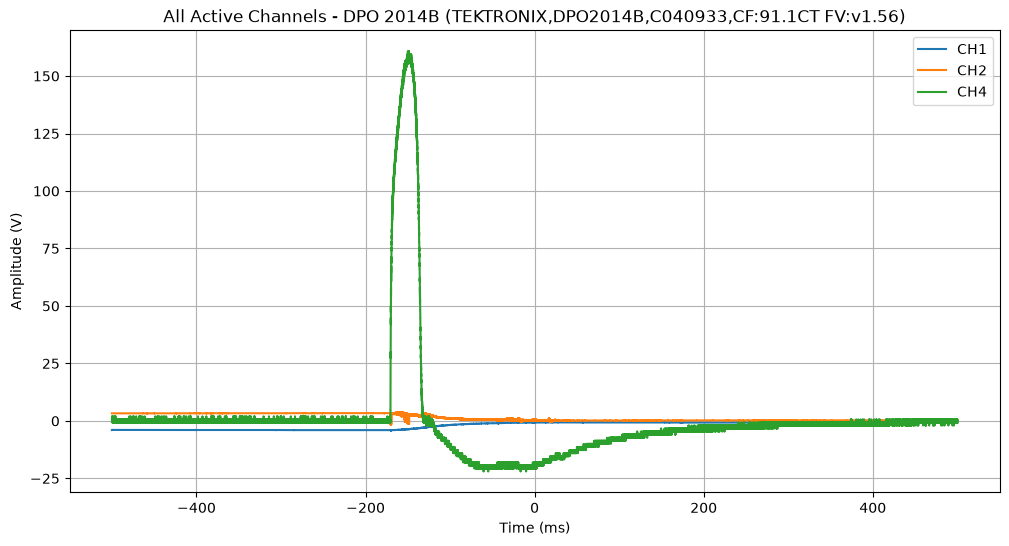

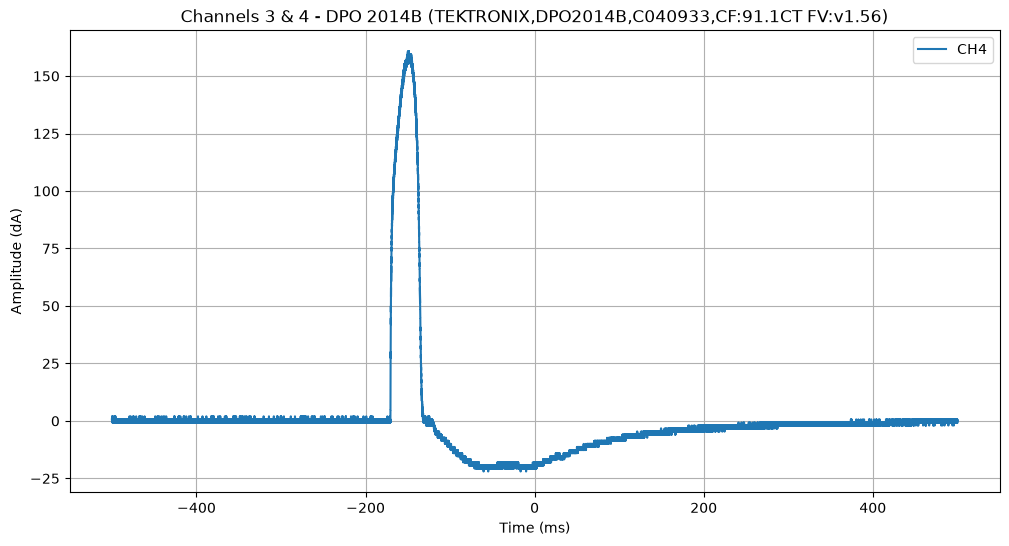

In [59]:
# Determine readable time scale units
max_time = np.max(np.abs(time_axis))
time_multiplier = 1.0
plot_time_unit = xunit

if max_time < 1e-6:
    time_multiplier = 1e9
    plot_time_unit = "ns"
elif max_time < 1e-3:
    time_multiplier = 1e6
    plot_time_unit = "µs"
elif max_time < 1.0:
    time_multiplier = 1e3
    plot_time_unit = "ms"

# Plot 1: All active channels
if waveforms:
    plt.figure(figsize=(12, 6))
    for ch in waveforms.keys():
        plt.plot(time_axis * time_multiplier, waveforms[ch], label=ch)
    plt.title(f"All Active Channels - DPO 2014B ({idn.strip()})")
    plt.xlabel(f"Time ({plot_time_unit})")
    plt.ylabel(f"Amplitude ({yunit})")
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot 2: CH3 and CH4 (last two channels)
ch3_ch4_active = [ch for ch in ["CH3", "CH4"] if ch in waveforms]
if ch3_ch4_active:
    plt.figure(figsize=(12, 6))
    for ch in ch3_ch4_active:
        plt.plot(time_axis * time_multiplier, waveforms[ch], label=ch)
    plt.title(f"Channels 3 & 4 - DPO 2014B ({idn.strip()})")
    plt.xlabel(f"Time ({plot_time_unit})")
    # plt.ylabel(f"Amplitude ({yunit})")
    plt.ylabel(f"Amplitude (dA)")
    plt.grid(True)
    plt.legend()
    plt.show()


## 6. Low-Pass Filtering

Applies a 4th-order Butterworth low-pass filter to the acquired signals using `scipy.signal.butter` and `scipy.signal.filtfilt` (zero-phase forward/backward filtering) to smooth out high-frequency noise.

Sampling Frequency (fs): 125000.00 Hz
Nyquist Frequency: 62500.00 Hz
Cutoff Frequency (fc): 3125.00 Hz


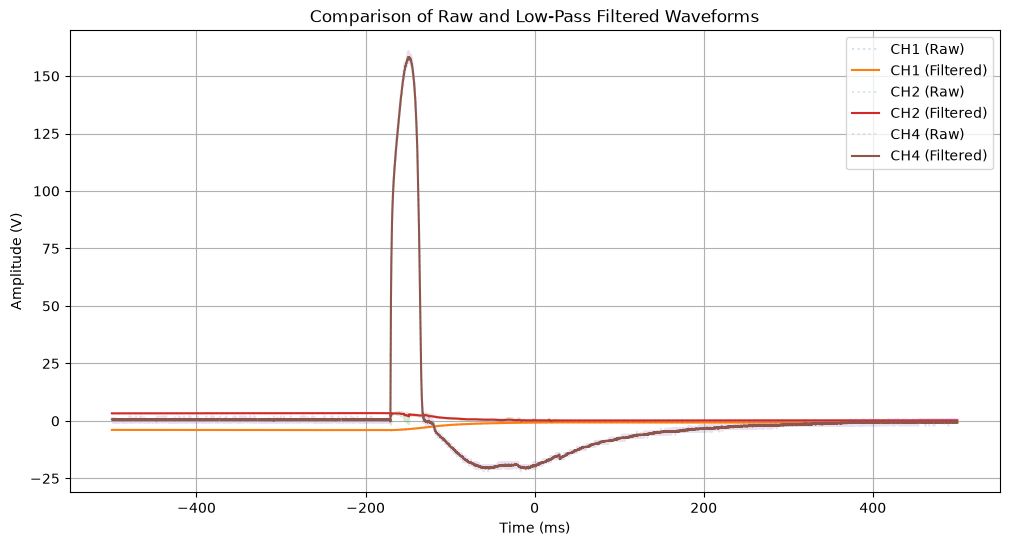

In [60]:
import scipy.signal

# 1. Calculate Sampling Parameters
first_ch = list(waveforms.keys())[0]
xincr = scaling_params[first_ch]["xincr"]
fs = 1.0 / xincr
nyquist = fs / 2.0

# Set cutoff frequency to 10% of the Nyquist limit (adjust as needed)
cutoff_freq = 0.05 * nyquist
filter_order = 4

print(f"Sampling Frequency (fs): {fs:.2f} Hz")
print(f"Nyquist Frequency: {nyquist:.2f} Hz")
print(f"Cutoff Frequency (fc): {cutoff_freq:.2f} Hz")

# Design 4th-order Butterworth low-pass filter
b, a = scipy.signal.butter(filter_order, cutoff_freq, fs=fs, btype='low')

# 2. Apply Filter to Waveforms
filtered_waveforms = {}
for ch, data in waveforms.items():
    filtered_waveforms[ch] = scipy.signal.filtfilt(b, a, data)

# 3. Plot Comparison of Raw vs Filtered Data
plt.figure(figsize=(12, 6))

time_multiplier = 1.0
plot_time_unit = xunit
max_time = np.max(np.abs(time_axis))

if max_time < 1e-6:
    time_multiplier = 1e9
    plot_time_unit = "ns"
elif max_time < 1e-3:
    time_multiplier = 1e6
    plot_time_unit = "µs"
elif max_time < 1.0:
    time_multiplier = 1e3
    plot_time_unit = "ms"

for ch in waveforms.keys():
    # Plot raw data (dotted)
    plt.plot(time_axis * time_multiplier, waveforms[ch], ':', label=f"{ch} (Raw)", alpha=0.2)
    # Plot filtered data (solid)
    plt.plot(time_axis * time_multiplier, filtered_waveforms[ch], '-', label=f"{ch} (Filtered)")

plt.title("Comparison of Raw and Low-Pass Filtered Waveforms")
plt.xlabel(f"Time ({plot_time_unit})")
plt.ylabel(f"Amplitude ({yunit})")
plt.grid(True)
plt.legend()
plt.show()


## 7. Save Comparison Plot

Saves the raw vs. filtered comparison plot as a high-resolution PNG image.

In [61]:
filtered_plot_filename = "plots/hill1.png"

# Re-create and save the comparison figure
plt.figure(figsize=(12, 6))
for ch in waveforms.keys():
    # Plot raw data (dotted)
    plt.plot(time_axis * time_multiplier, waveforms[ch], ':', label=f"{ch} (Raw)", alpha=0.5)
    # Plot filtered data (solid)
    plt.plot(time_axis * time_multiplier, filtered_waveforms[ch], '-', label=f"{ch} (Filtered)")

plt.title("Comparison of Raw and Low-Pass Filtered Waveforms")
plt.xlabel(f"Time ({plot_time_unit})")
plt.ylabel(f"Amplitude ({yunit})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(filtered_plot_filename, dpi=150)
plt.close()  # Close the plot to avoid double rendering in notebook
print(f"Comparison plot saved successfully as '{filtered_plot_filename}'.")


Comparison plot saved successfully as 'plots/hill1.png'.


## 8. Export to CSV

Exports the time, raw, and filtered voltage arrays to a CSV file.

In [62]:
csv_filename = "data/hill1.csv"

# Build columns list and header list dynamically
columns = [time_axis]
header_parts = [f"Time ({xunit})"]

for ch in waveforms.keys():
    # Raw column
    columns.append(waveforms[ch])
    header_parts.append(f"{ch}_Raw ({yunit})")
    
    # Filtered column (if available)
    if 'filtered_waveforms' in locals() and ch in filtered_waveforms:
        columns.append(filtered_waveforms[ch])
        header_parts.append(f"{ch}_Filtered ({yunit})")

csv_header = ",".join(header_parts)
csv_data = np.column_stack(columns)
np.savetxt(csv_filename, csv_data, delimiter=",", header=csv_header, comments="")
print(f"Saved data to {csv_filename}")


Saved data to data/hill1.csv


## 9. Disconnect

Close the connection to the oscilloscope and clean up the DeviceManager.

In [63]:
# dm.close()
# print("DeviceManager closed. Connection ended.")
